Name: NAGARAMPALLI SARVAN KUMAR

Roll Number: CH.SC.U4CSE24130

In [1]:
import zipfile
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Dataset: `Ch02/digits.zip` from [pbharrin/machinelearninginaction](https://github.com/pbharrin/machinelearninginaction/tree/master/Ch02). Each handwritten digit is a 32x32 grid of 0s and 1s stored as a text file named `<digit>_<index>.txt`, split into `trainingDigits/` and `testDigits/`.

In [2]:
def img2vector(text):
    # flatten a 32x32 text image into a 1x1024 vector
    return np.array([int(ch) for line in text.split() for ch in line[:32]])

def load_digits(zip_path, folder):
    X, y = [], []
    with zipfile.ZipFile(zip_path) as z:
        for name in z.namelist():
            if name.startswith(folder + '/') and name.endswith('.txt'):
                X.append(img2vector(z.read(name).decode()))
                y.append(int(name.split('/')[1].split('_')[0]))
    return np.array(X), np.array(y)

In [3]:
X_train, y_train = load_digits('digits.zip', 'trainingDigits')
X_test, y_test = load_digits('digits.zip', 'testDigits')
print("Training samples:", X_train.shape)
print("Test samples:", X_test.shape)

Training samples: (1934, 1024)
Test samples: (946, 1024)


In [4]:
pd.Series(y_train).value_counts().sort_index()

0    189
1    198
2    195
3    199
4    186
5    187
6    195
7    201
8    180
9    204
Name: count, dtype: int64

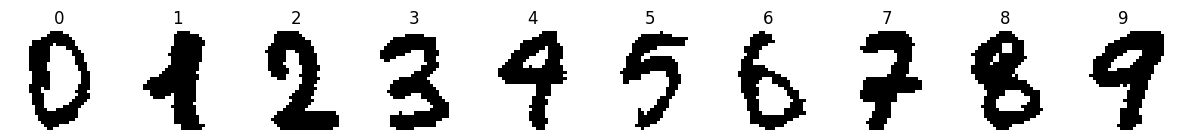

In [5]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for digit, ax in enumerate(axes):
    ax.imshow(X_train[y_train == digit][0].reshape(32, 32), cmap='gray_r')
    ax.set_title(digit); ax.axis('off')
plt.show()

kNN classifier from the book (`classify0`), ported to Python 3: compute the Euclidean distance to every training sample, take the k nearest, and return the majority label.

In [6]:
def classify0(inX, dataSet, labels, k):
    distances = np.sqrt(((dataSet - inX) ** 2).sum(axis=1))
    nearest = labels[distances.argsort()[:k]]
    return Counter(nearest).most_common(1)[0][0]

In [7]:
predictions = np.array([classify0(x, X_train, y_train, 3) for x in X_test])

In [8]:
print("Actual vs Predicted Digit")
print("---------------------------")
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})
print(comparison_df)

Actual vs Predicted Digit
---------------------------
     Actual  Predicted
0         0          0
1         0          0
2         0          0
3         0          0
4         0          0
..      ...        ...
941       9          9
942       9          9
943       9          9
944       9          9
945       9          9

[946 rows x 2 columns]


In [9]:
acc = accuracy_score(y_test, predictions)

print("Classification Evaluation Metrics")
print("---------------------------")
print(f"Accuracy: {acc:.4f}")
print(f"Errors: {(predictions != y_test).sum()} out of {len(y_test)}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Evaluation Metrics
---------------------------
Accuracy: 0.9884
Errors: 11 out of 946
Confusion Matrix:
[[ 87   0   0   0   0   0   0   0   0   0]
 [  0  96   0   0   0   0   0   1   0   0]
 [  0   0  92   0   0   0   0   0   0   0]
 [  0   0   0  84   0   0   0   0   0   1]
 [  0   0   0   0 114   0   0   0   0   0]
 [  0   0   0   1   0 106   1   0   0   0]
 [  0   0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0   0  96   0   0]
 [  0   2   0   1   0   0   1   0  87   0]
 [  0   1   0   0   0   1   0   1   0  86]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        87
           1       0.97      0.99      0.98        97
           2       1.00      1.00      1.00        92
           3       0.98      0.99      0.98        85
           4       1.00      1.00      1.00       114
           5       0.99      0.98      0.99       108
           6       0.98      1.00      0.99     

The same model using scikit-learn's `KNeighborsClassifier` (k=3, Euclidean distance) for comparison.

In [10]:
model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
model.fit(X_train, y_train)
print(f"scikit-learn kNN accuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

scikit-learn kNN accuracy: 0.9884

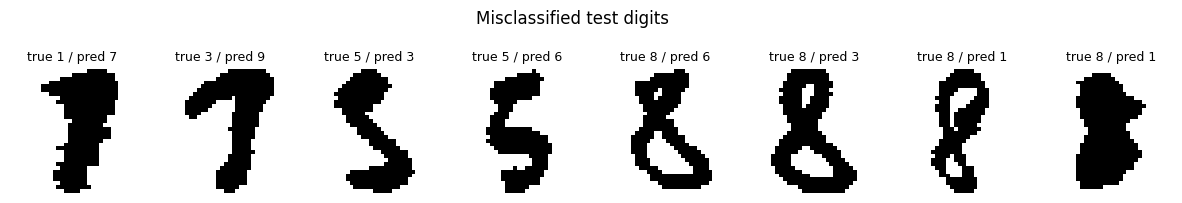

In [11]:
wrong = np.where(predictions != y_test)[0]
fig, axes = plt.subplots(1, len(wrong[:8]), figsize=(15, 2.5))
for ax, i in zip(np.atleast_1d(axes), wrong[:8]):
    ax.imshow(X_test[i].reshape(32, 32), cmap='gray_r')
    ax.set_title(f"true {y_test[i]} / pred {predictions[i]}", fontsize=9); ax.axis('off')
plt.suptitle('Misclassified test digits')
plt.show()

Identifying a new handwritten sample: pick one test image the classifier has never seen and find its nearest neighbours.

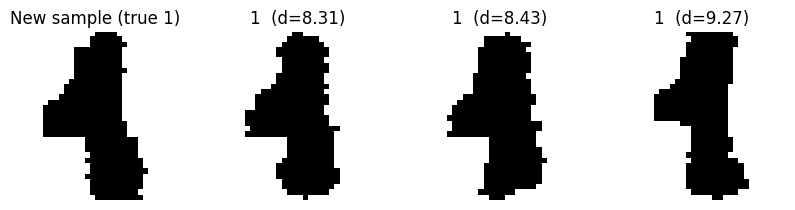

Predicted digit: 1


In [12]:
new_digit, true_label = X_test[100], y_test[100]
distances = np.sqrt(((X_train - new_digit) ** 2).sum(axis=1))
nearest = distances.argsort()[:3]

fig, axes = plt.subplots(1, 4, figsize=(10, 2.5))
axes[0].imshow(new_digit.reshape(32, 32), cmap='gray_r'); axes[0].set_title(f"New sample (true {true_label})")
for ax, i in zip(axes[1:], nearest):
    ax.imshow(X_train[i].reshape(32, 32), cmap='gray_r'); ax.set_title(f"{y_train[i]}  (d={distances[i]:.2f})")
for ax in axes: ax.axis('off')
plt.show()
print("Predicted digit:", classify0(new_digit, X_train, y_train, 3))